In [78]:
!pip install wordcloud -q

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [80]:
import pandas as pd

file_id = "1e0P3tBsQaCCGe5CkpDm_5LXiXA05LwuA"
url = f"https://drive.google.com/uc?id={file_id}&export=download"

df = pd.read_excel(url)
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded: 2304 rows, 4 columns


In [81]:
print(df.columns.tolist())
print(df['Rating'].value_counts().sort_index())
print(df.isnull().sum())

['Unnamed: 0', 'Product_name', 'Review', 'Rating']
Rating
1     184
2      46
3     140
4     552
5    1382
Name: count, dtype: int64
Unnamed: 0      0
Product_name    0
Review          8
Rating          0
dtype: int64


In [82]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df.dropna(subset=['Review', 'Rating'], inplace=True)
print(f"After cleaning: {df.shape[0]} rows remain")
print(f"Columns: {df.columns.tolist()}")

After cleaning: 2296 rows remain
Columns: ['Product_name', 'Review', 'Rating']


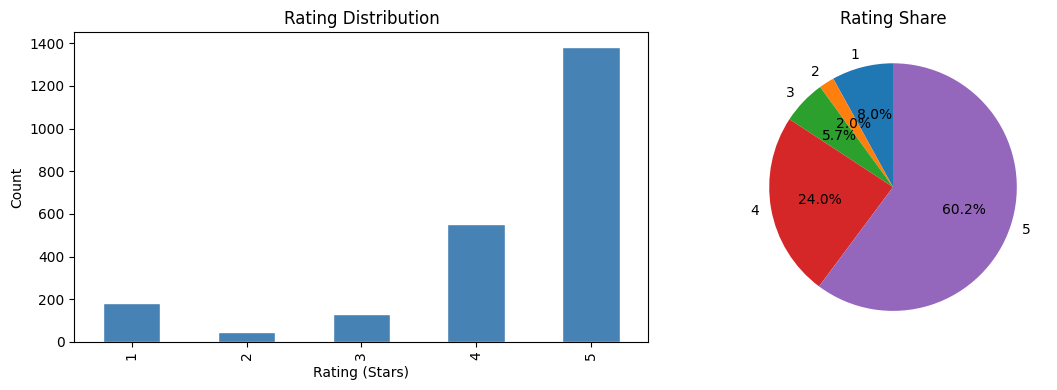

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating (Stars)')
axes[0].set_ylabel('Count')

df['Rating'].value_counts().sort_index().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Rating Share')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

count    2296.0
mean       33.9
std        30.1
min         1.0
25%         6.0
50%        26.0
75%        56.0
max       103.0
Name: review_length, dtype: float64


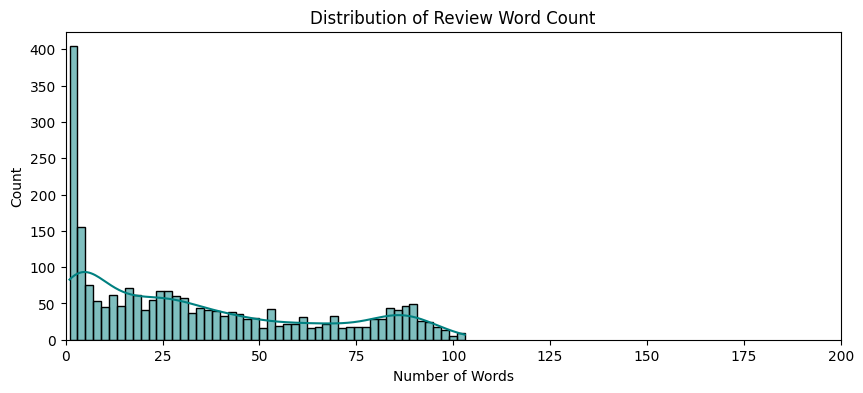


Avg review length by rating:
Rating
1    30.2
2    33.4
3    35.3
4    40.1
5    31.8
Name: review_length, dtype: float64


In [84]:
df['review_length'] = df['Review'].apply(lambda x: len(str(x).split()))

print(df['review_length'].describe().round(1))

plt.figure(figsize=(10, 4))
sns.histplot(df['review_length'], bins=50, kde=True, color='teal')
plt.title('Distribution of Review Word Count')
plt.xlabel('Number of Words')
plt.xlim(0, 200)
plt.show()

print("\nAvg review length by rating:")
print(df.groupby('Rating')['review_length'].mean().round(1))

In [85]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download(['stopwords', 'wordnet', 'punkt'])

lemma = WordNetLemmatizer()
stops = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    return ' '.join(lemma.lemmatize(w) for w in text.split() if w not in stops)

df['clean_review'] = df['Review'].apply(clean_text)
print("Text cleaning done!")
print(df[['Review', 'clean_review']].head(3))

Text cleaning done!
                                              Review  \
0  Best under 60k Great performanceI got it for a...   
1                                 Good perfomence...   
2  Great performance but usually it has also that...   

                                        clean_review  
0  best k great performancei got around battery b...  
1                                    good perfomence  
2  great performance usually also gaming laptop i...  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


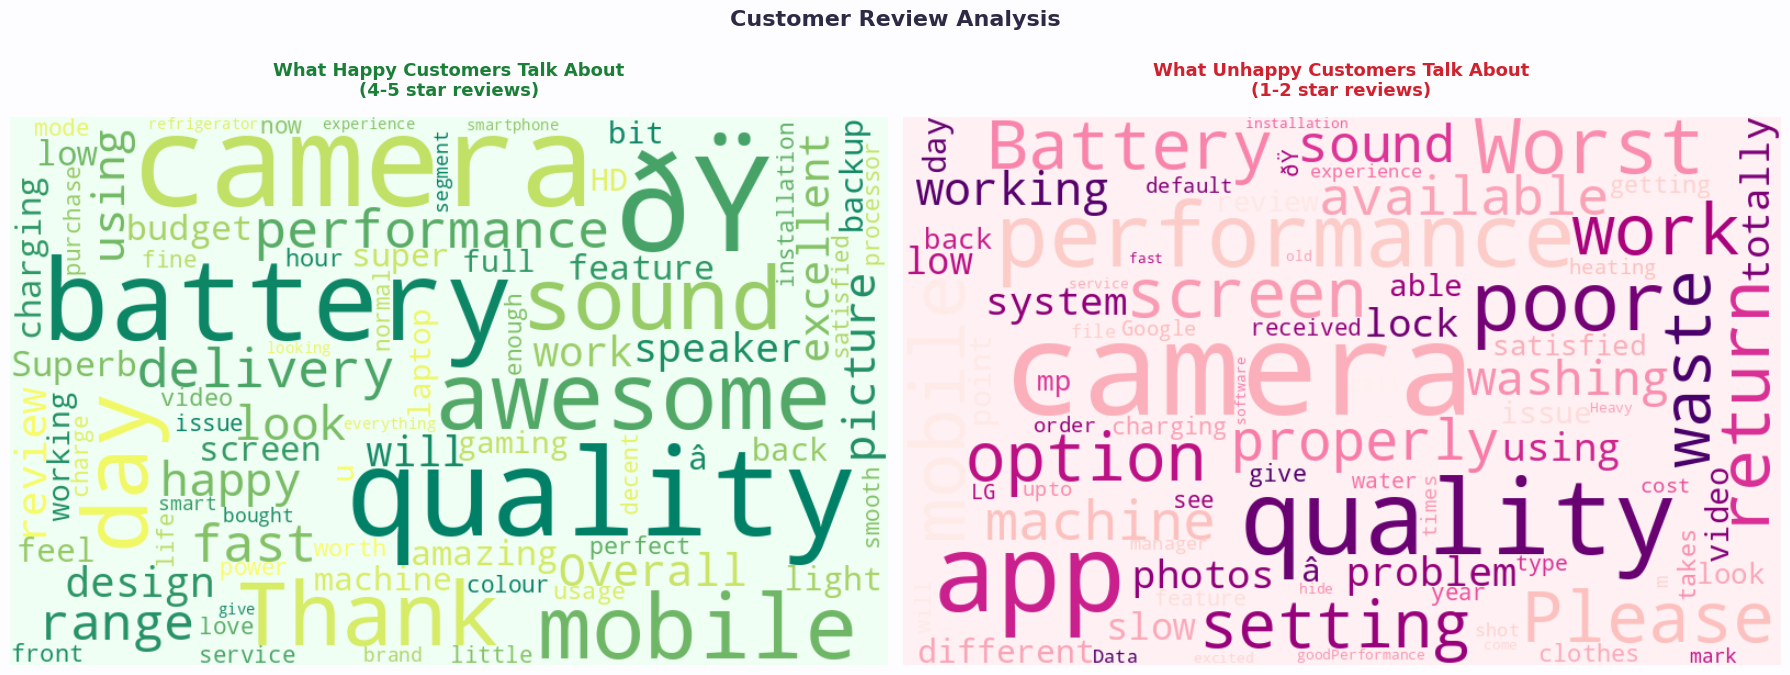

In [86]:
from wordcloud import WordCloud, STOPWORDS

# Extended stopwords to remove meaningless words
custom_stops = STOPWORDS.union({
    'phone', 'product', 'buy', 'good', 'bad', 'time', 'one',
    'got', 'get', 'use', 'used', 'also', 'much', 'really',
    'even', 'would', 'could', 'thing', 'way', 'make', 'go',
    'well', 'take', 'say', 'need', 'want', 'first', 'still',
    'tv', 'flipkart', 'samsung', 'realme', 'monitor', 'display',
    'price', 'money', 'value', 'better', 'best', 'great', 'nice'
})

pos_text = ' '.join(df[df['Rating'] >= 4]['Review'].astype(str))
neg_text = ' '.join(df[df['Rating'] <= 2]['Review'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#fdfcff')

wc_pos = WordCloud(
    width=800, height=500,
    background_color='#f0fff4',
    colormap='summer',
    max_words=80,
    stopwords=custom_stops,
    prefer_horizontal=0.85,
    min_font_size=10,
    max_font_size=120,
    collocations=False
).generate(pos_text)

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('What Happy Customers Talk About\n(4-5 star reviews)',
                  fontsize=13, fontweight='bold', color='#1a7f37', pad=15)

wc_neg = WordCloud(
    width=800, height=500,
    background_color='#fff0f3',
    colormap='RdPu',
    max_words=80,
    stopwords=custom_stops,
    prefer_horizontal=0.85,
    min_font_size=10,
    max_font_size=120,
    collocations=False
).generate(neg_text)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('What Unhappy Customers Talk About\n(1-2 star reviews)',
                  fontsize=13, fontweight='bold', color='#cf222e', pad=15)

plt.suptitle('Customer Review Analysis',
             fontsize=16, fontweight='bold', color='#2d2a45', y=1.02)
plt.tight_layout()
plt.savefig('graph2_wordcloud.png', dpi=150,
            bbox_inches='tight', facecolor='#fdfcff')
plt.show()

In [87]:
def label_sentiment(r):
    if r >= 4: return 'Positive'
    elif r == 3: return 'Neutral'
    else: return 'Negative'

df['Sentiment'] = df['Rating'].apply(label_sentiment)
print(df['Sentiment'].value_counts())

Sentiment
Positive    1934
Negative     230
Neutral      132
Name: count, dtype: int64


In [88]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_review'])
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training size: {X_train.shape[0]}")
print(f"Testing size:  {X_test.shape[0]}")

Training size: 1836
Testing size:  460


In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Naive Bayes':         MultinomialNB(),
    'Random Forest':       RandomForestClassifier(class_weight='balanced', n_estimators=100)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'Accuracy': round(acc, 3), 'F1 Score': round(f1, 3)}
    print(f"{name:25s} → Accuracy: {acc:.3f} | F1: {f1:.3f}")

Logistic Regression       → Accuracy: 0.887 | F1: 0.899
Naive Bayes               → Accuracy: 0.846 | F1: 0.777
Random Forest             → Accuracy: 0.896 | F1: 0.902


              precision    recall  f1-score   support

    Negative       0.90      0.83      0.86        46
     Neutral       0.35      0.69      0.47        26
    Positive       0.96      0.91      0.93       388

    accuracy                           0.89       460
   macro avg       0.74      0.81      0.75       460
weighted avg       0.92      0.89      0.90       460



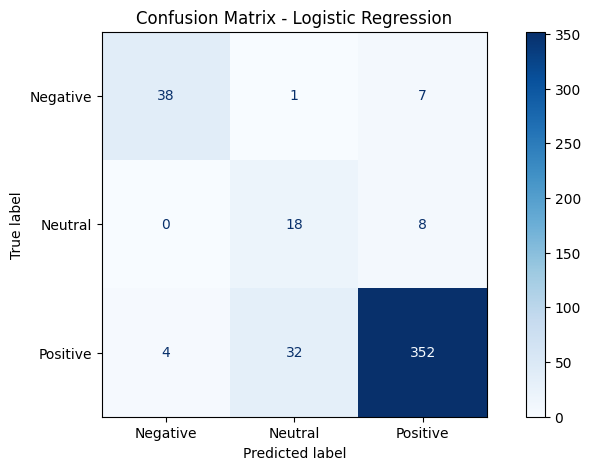

In [90]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best_model = models['Logistic Regression']
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test,
    display_labels=['Negative','Neutral','Positive'],
    cmap='Blues'
)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

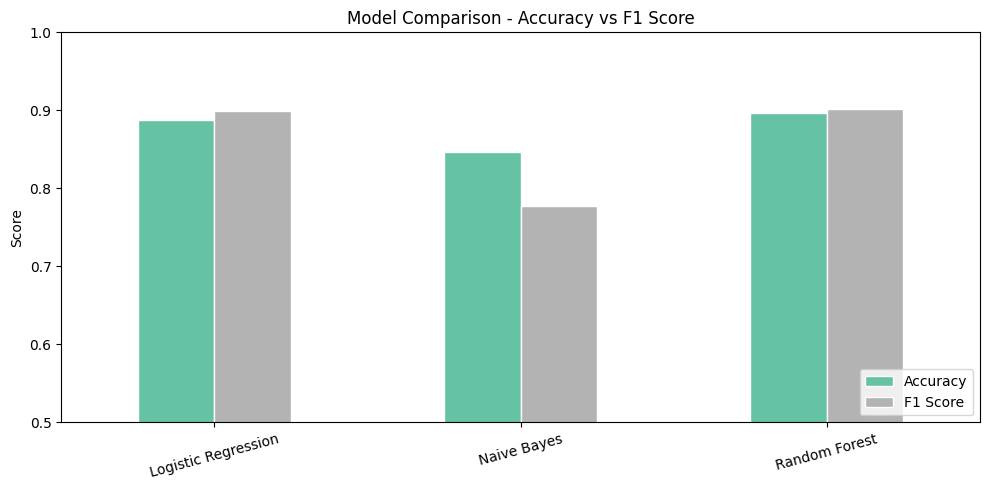

In [91]:
results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Model Comparison - Accuracy vs F1 Score')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [92]:
!pip install vaderSentiment -q

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def vader_label(text):
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05: return 'Positive'
    elif score <= -0.05: return 'Negative'
    else: return 'Neutral'

df['vader_sentiment'] = df['Review'].apply(vader_label)

# Compare VADER vs Rating-based labels
from sklearn.metrics import accuracy_score
vader_acc = accuracy_score(df['Sentiment'], df['vader_sentiment'])
print(f"VADER vs Rating-label agreement: {vader_acc:.2%}")
print(df['vader_sentiment'].value_counts())

VADER vs Rating-label agreement: 86.50%
vader_sentiment
Positive    1979
Negative     226
Neutral       91
Name: count, dtype: int64


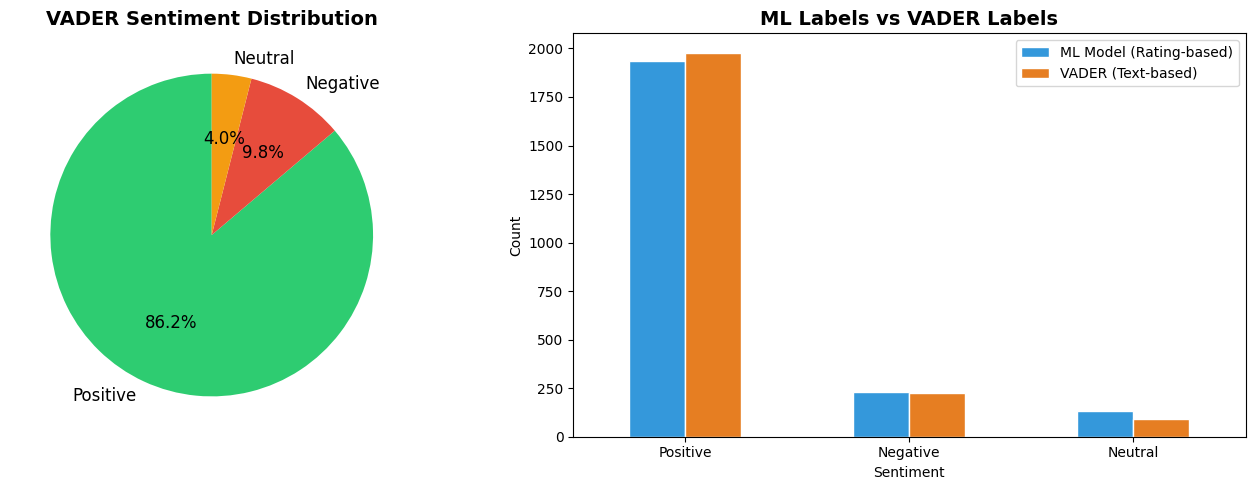


 VADER vs Rating-label agreement: 86.50%
 Mismatched reviews (text vs rating): 93 out of 2296


In [93]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VADER distribution
vader_counts = df['vader_sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12']
axes[0].pie(vader_counts, labels=vader_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('VADER Sentiment Distribution', fontsize=14, fontweight='bold')

# ML model vs VADER comparison
comparison = pd.DataFrame({
    'ML Model (Rating-based)': df['Sentiment'].value_counts(),
    'VADER (Text-based)':      df['vader_sentiment'].value_counts()
})
comparison.plot(kind='bar', ax=axes[1], color=['#3498db', '#e67e22'], edgecolor='white')
axes[1].set_title('ML Labels vs VADER Labels', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"\n VADER vs Rating-label agreement: 86.50%")
print(f" Mismatched reviews (text vs rating): 93 out of {len(df)}")

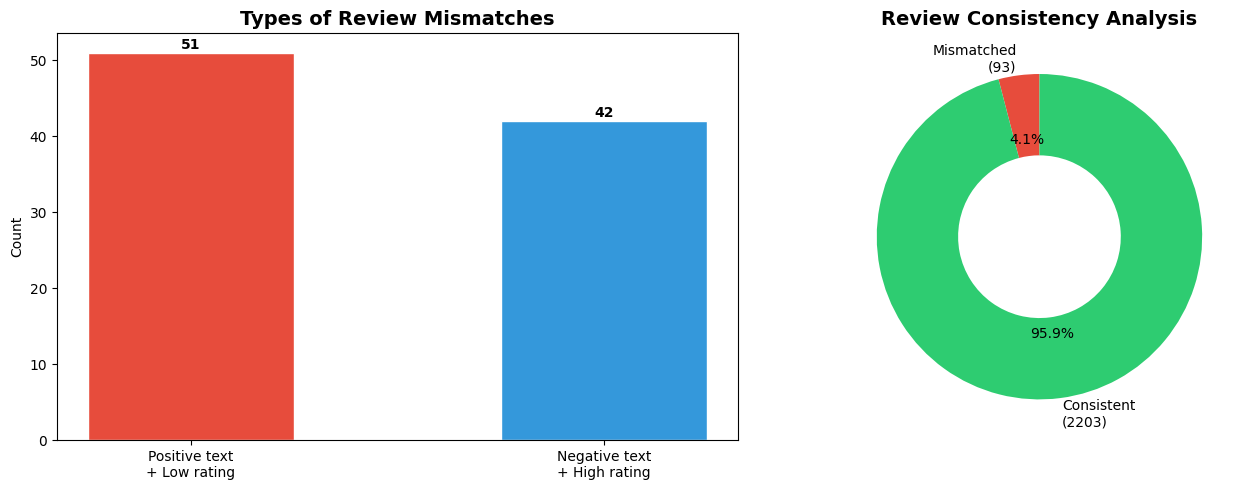

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mismatch types breakdown
mismatch_types = {
    'Positive text\n+ Low rating': len(df[(df['vader_sentiment']=='Positive') & (df['Rating']<=2)]),
    'Negative text\n+ High rating': len(df[(df['vader_sentiment']=='Negative') & (df['Rating']>=4)])
}
axes[0].bar(mismatch_types.keys(), mismatch_types.values(),
            color=['#e74c3c', '#3498db'], edgecolor='white', width=0.5)
axes[0].set_title('Types of Review Mismatches', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(mismatch_types.items()):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Mismatch vs match donut chart
sizes = [93, len(df) - 93]
labels = ['Mismatched\n(93)', f'Consistent\n({len(df)-93})']
wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'], startangle=90,
    wedgeprops=dict(width=0.5)
)
axes[1].set_title('Review Consistency Analysis', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [95]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

neg_reviews = df[df['Sentiment'] == 'Negative']['clean_review']

cv = CountVectorizer(max_features=1000)
X_neg = cv.fit_transform(neg_reviews)

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X_neg)

words = cv.get_feature_names_out()
print("LDA model trained successfully!")
print(f"Trained on {len(neg_reviews)} negative reviews")

LDA model trained successfully!
Trained on 230 negative reviews


Text(0.5, 1.02, 'LDA Topic Modelling — What Customers Complain About')

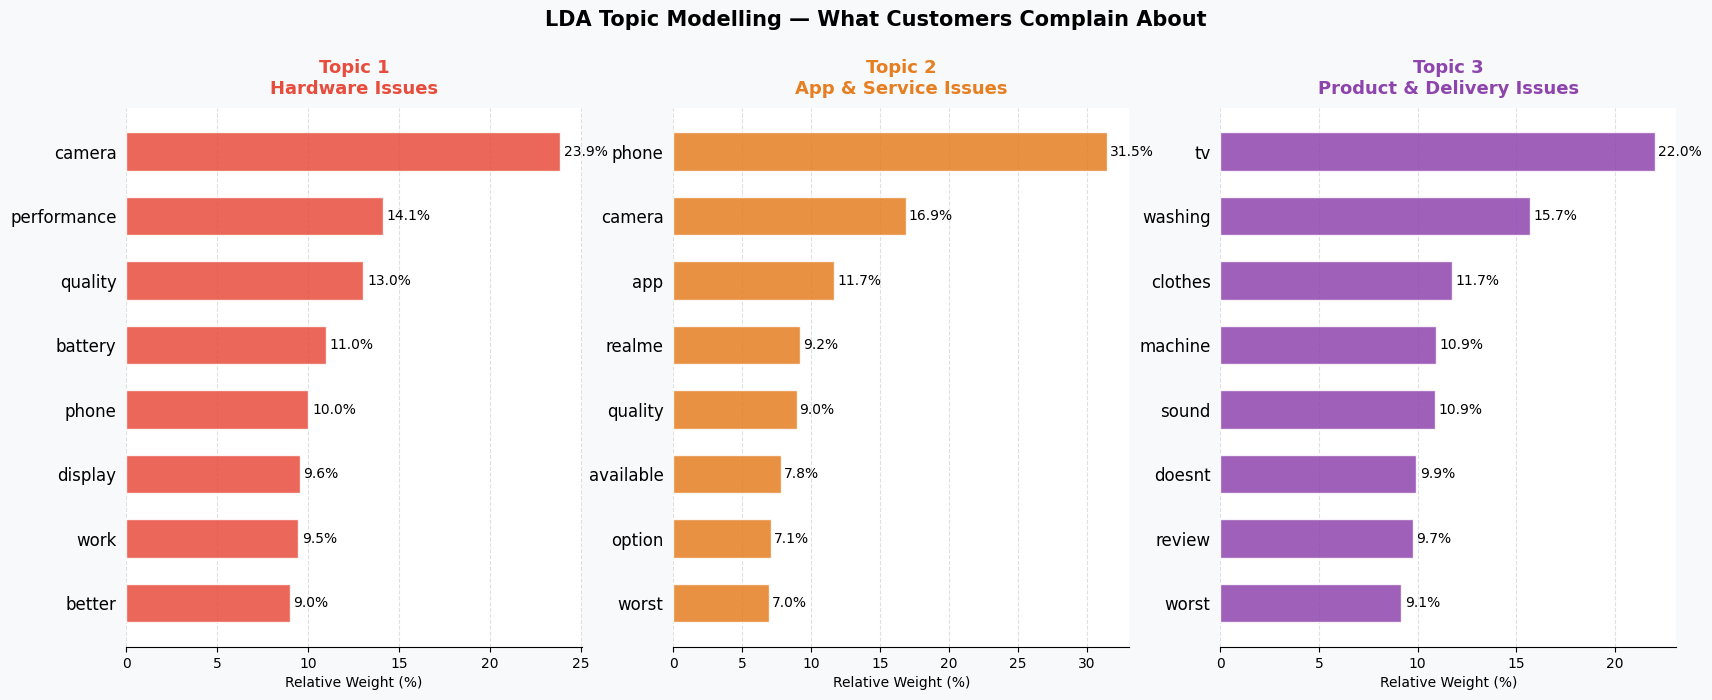

In [96]:
lda_stopwords = {
    'dont', 'poor', 'mobile', 'good', 'bad', 'buy', 'like',
    'get', 'also', 'one', 'use', 'even', 'much', 'really',
    'would', 'could', 'thing', 'way', 'make', 'got', 'going',
    'said', 'still', 'time', 'product', 'flipkart'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='#f8f9fa')

topic_labels = ['Hardware Issues', 'App & Service Issues', 'Product & Delivery Issues']
colors = ['#e74c3c', '#e67e22', '#8e44ad']

for i, ax in enumerate(axes):
    topic = lda.components_[i]

    # Filter out useless words
    filtered = [(words[j], topic[j]) for j in topic.argsort()[::-1]
                if words[j] not in lda_stopwords][:8]

    top_w = [w for w, s in filtered]
    top_s = [s for w, s in filtered]
    total = sum(top_s)
    top_pct = [s/total*100 for s in top_s]

    bars = ax.barh(range(len(top_w)), top_pct,
                   color=colors[i], alpha=0.85, height=0.6,
                   edgecolor='white')

    ax.set_yticks(range(len(top_w)))
    ax.set_yticklabels(top_w, fontsize=12, fontweight='500')
    ax.invert_yaxis()
    ax.set_facecolor('#ffffff')
    ax.set_title(f'Topic {i+1}\n{topic_labels[i]}',
                 fontsize=13, fontweight='bold', color=colors[i], pad=10)
    ax.set_xlabel('Relative Weight (%)', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    for bar, pct in zip(bars, top_pct):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=10)

fig.suptitle('LDA Topic Modelling — What Customers Complain About',
             fontsize=15, fontweight='bold', y=1.02)

In [97]:
print("=" * 60)
print("      🤖 LIVE SENTIMENT PREDICTOR")
print("=" * 60)

def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    vector = tfidf.transform([cleaned])
    ml_pred = models['Random Forest'].predict(vector)[0]
    vader = vader_label(review_text)

    emoji = {'Positive': '✅', 'Negative': '❌', 'Neutral': '⚠️'}
    print(f"\n Review : {review_text[:80]}")
    print(f" ML Model  : {emoji[ml_pred]}  {ml_pred}")
    print(f" VADER     : {emoji[vader]}  {vader}")
    if ml_pred == vader:
        print(f" Both models AGREE!")
    else:
        print(f" Models DISAGREE — interesting case!")
    print("─" * 60)

predict_sentiment("This laptop is absolutely amazing, super fast delivery!")
predict_sentiment("Worst product ever, stopped working after 2 days.")
predict_sentiment("Average product, nothing special about it.")
predict_sentiment("Camera quality is very poor but battery life is good.")

      🤖 LIVE SENTIMENT PREDICTOR

 Review : This laptop is absolutely amazing, super fast delivery!
 ML Model  : ✅  Positive
 VADER     : ✅  Positive
 Both models AGREE!
────────────────────────────────────────────────────────────

 Review : Worst product ever, stopped working after 2 days.
 ML Model  : ❌  Negative
 VADER     : ❌  Negative
 Both models AGREE!
────────────────────────────────────────────────────────────

 Review : Average product, nothing special about it.
 ML Model  : ✅  Positive
 VADER     : ❌  Negative
 Models DISAGREE — interesting case!
────────────────────────────────────────────────────────────

 Review : Camera quality is very poor but battery life is good.
 ML Model  : ✅  Positive
 VADER     : ✅  Positive
 Both models AGREE!
────────────────────────────────────────────────────────────
